R_L(\Omega),U(V),I(mA)
0,0.396,51.0
20,1.03,50.5
40,2.01,49.9
60,2.96,49.7
80,3.90,48.9
100,4.82,48.5

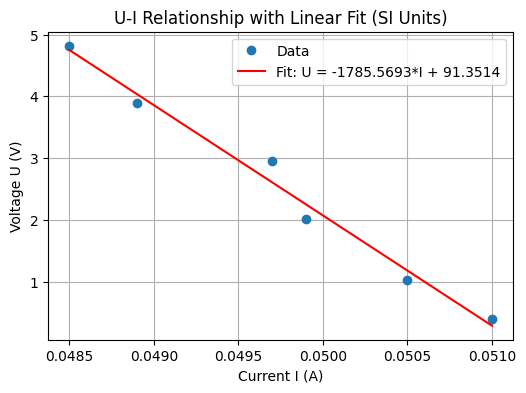

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO
import numpy as np

# Prepare data (SI units: I in A, U in V, R_L in Ohm)
data = '''R_L(Ohm),U(V),I(A)
0,0.396,0.0510
20,1.03,0.0505
40,2.01,0.0499
60,2.96,0.0497
80,3.90,0.0489
100,4.82,0.0485'''
df = pd.read_csv(StringIO(data))

# Least squares linear fit: U = a * I + b
I = df['I(A)'].values
U = df['U(V)'].values
A = np.vstack([I, np.ones(len(I))]).T
a, b = np.linalg.lstsq(A, U, rcond=None)[0]

# Plot U vs I and fitted line
plt.figure(figsize=(6,4))
plt.plot(I, U, 'o', label='Data')
plt.plot(I, a*I + b, 'r-', label=f'Fit: U = {a:.4f}*I + {b:.4f}')
plt.xlabel('Current I (A)')
plt.ylabel('Voltage U (V)')
plt.title('U-I Relationship with Linear Fit (SI Units)')
plt.legend()
plt.grid(True)
plt.savefig('ui_relationship2.png')
plt.show()

In [7]:
import numpy as np

# Least squares linear fit: U = a * I + b
I = df['I(mA)'].values
U = df['U(V)'].values
A = np.vstack([I, np.ones(len(I))]).T
a, b = np.linalg.lstsq(A, U, rcond=None)[0]

print(f"Fitted line: U = {a:.4f} * I + {b:.4f}")

KeyError: 'I(mA)'